# Ultrasound Image Preprocessing Pipeline (FIXED)

## Key Improvements:
1. **Google Drive integration** - Load data from Drive and save processed data back
2. **No artificial augmentation during preprocessing** - Keep original images only
3. **Proper resizing** - Resize to 224x224 (standard for ResNet/ImageNet models)
4. **Intensity normalization** - Per-image min-max normalization
5. **Metadata tracking** - Save image source info to enable group-level splitting later
6. **Quality checks** - Verify all images are processed correctly

## What NOT to do:
- ❌ Don't create augmented copies during preprocessing (do this during training instead)
- ❌ Don't mix images from same patient in train/val (handle via group splitting)
- ❌ Don't normalize across entire dataset (normalize per-image)

## Step 0: Mount Google Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')
print("✓ Google Drive mounted successfully")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted successfully


## Step 0.5: Verify Google Drive Directory Structure

**This cell checks if your data is in the correct location on Google Drive.**

## Step 1: Import Libraries

In [ ]:
import os
import sys
import json
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## Step 2: Configuration

In [5]:
# Google Drive paths
DRIVE_BASE = Path('/content/drive/MyDrive/Data/liver')
RAW_DATA_DIR = DRIVE_BASE / 'Dataset' / 'Dataset'  # Raw images location
OUTPUT_DIR = DRIVE_BASE / 'processed'  # Processed output location

# Processing parameters
TARGET_SIZE = (224, 224)  # Standard size for ResNet models
NORMALIZE_METHOD = 'per_image'  # 'per_image' or 'global'

# Classes to process
CLASSES_TO_PROCESS = ['F0', 'F1', 'F2', 'F3', 'F4']

print(f"Raw data directory: {RAW_DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Target size: {TARGET_SIZE}")
print(f"Classes to process: {CLASSES_TO_PROCESS}")

Raw data directory: /content/drive/MyDrive/Data/liver/Dataset/Dataset
Output directory: /content/drive/MyDrive/Data/liver/processed
Target size: (224, 224)
Classes to process: ['F0', 'F1', 'F2', 'F3', 'F4']


## Step 3: Explore Raw Data

In [6]:
# Verify data directory exists
if not RAW_DATA_DIR.exists():
    raise FileNotFoundError(f"Raw data directory not found: {RAW_DATA_DIR}")

# List all classes
all_classes = sorted([d.name for d in RAW_DATA_DIR.iterdir() if d.is_dir()])
print(f"Found classes: {all_classes}")

# Count images per class
print("\nImages per class:")
for cls in all_classes:
    cls_path = RAW_DATA_DIR / cls
    n_images = len([f for f in cls_path.iterdir() if f.is_file()])
    print(f"  {cls}: {n_images} images")

Found classes: ['F0', 'F1', 'F2', 'F3', 'F4']

Images per class:
  F0: 2114 images
  F1: 861 images
  F2: 793 images
  F3: 857 images
  F4: 1698 images


In [7]:
# Analyze image dimensions
print("\nAnalyzing image dimensions...\n")

for cls in all_classes:
    cls_path = RAW_DATA_DIR / cls
    shapes = []

    for img_file in cls_path.iterdir():
        if not img_file.is_file():
            continue
        try:
            with Image.open(img_file) as im:
                shapes.append(im.size)  # (width, height)
        except Exception as e:
            print(f"  Warning: Could not read {img_file.name}: {e}")

    # Count unique dimensions
    dim_counts = Counter(shapes)
    top_dims = dim_counts.most_common(5)

    print(f"Class {cls}:")
    for (w, h), count in top_dims:
        print(f"  {w}x{h}: {count} images")
    print()


Analyzing image dimensions...

Class F0:
  640x480: 2114 images

Class F1:
  449x464: 489 images
  640x480: 372 images

Class F2:
  449x464: 793 images

Class F3:
  449x464: 857 images

Class F4:
  640x480: 973 images
  449x464: 725 images



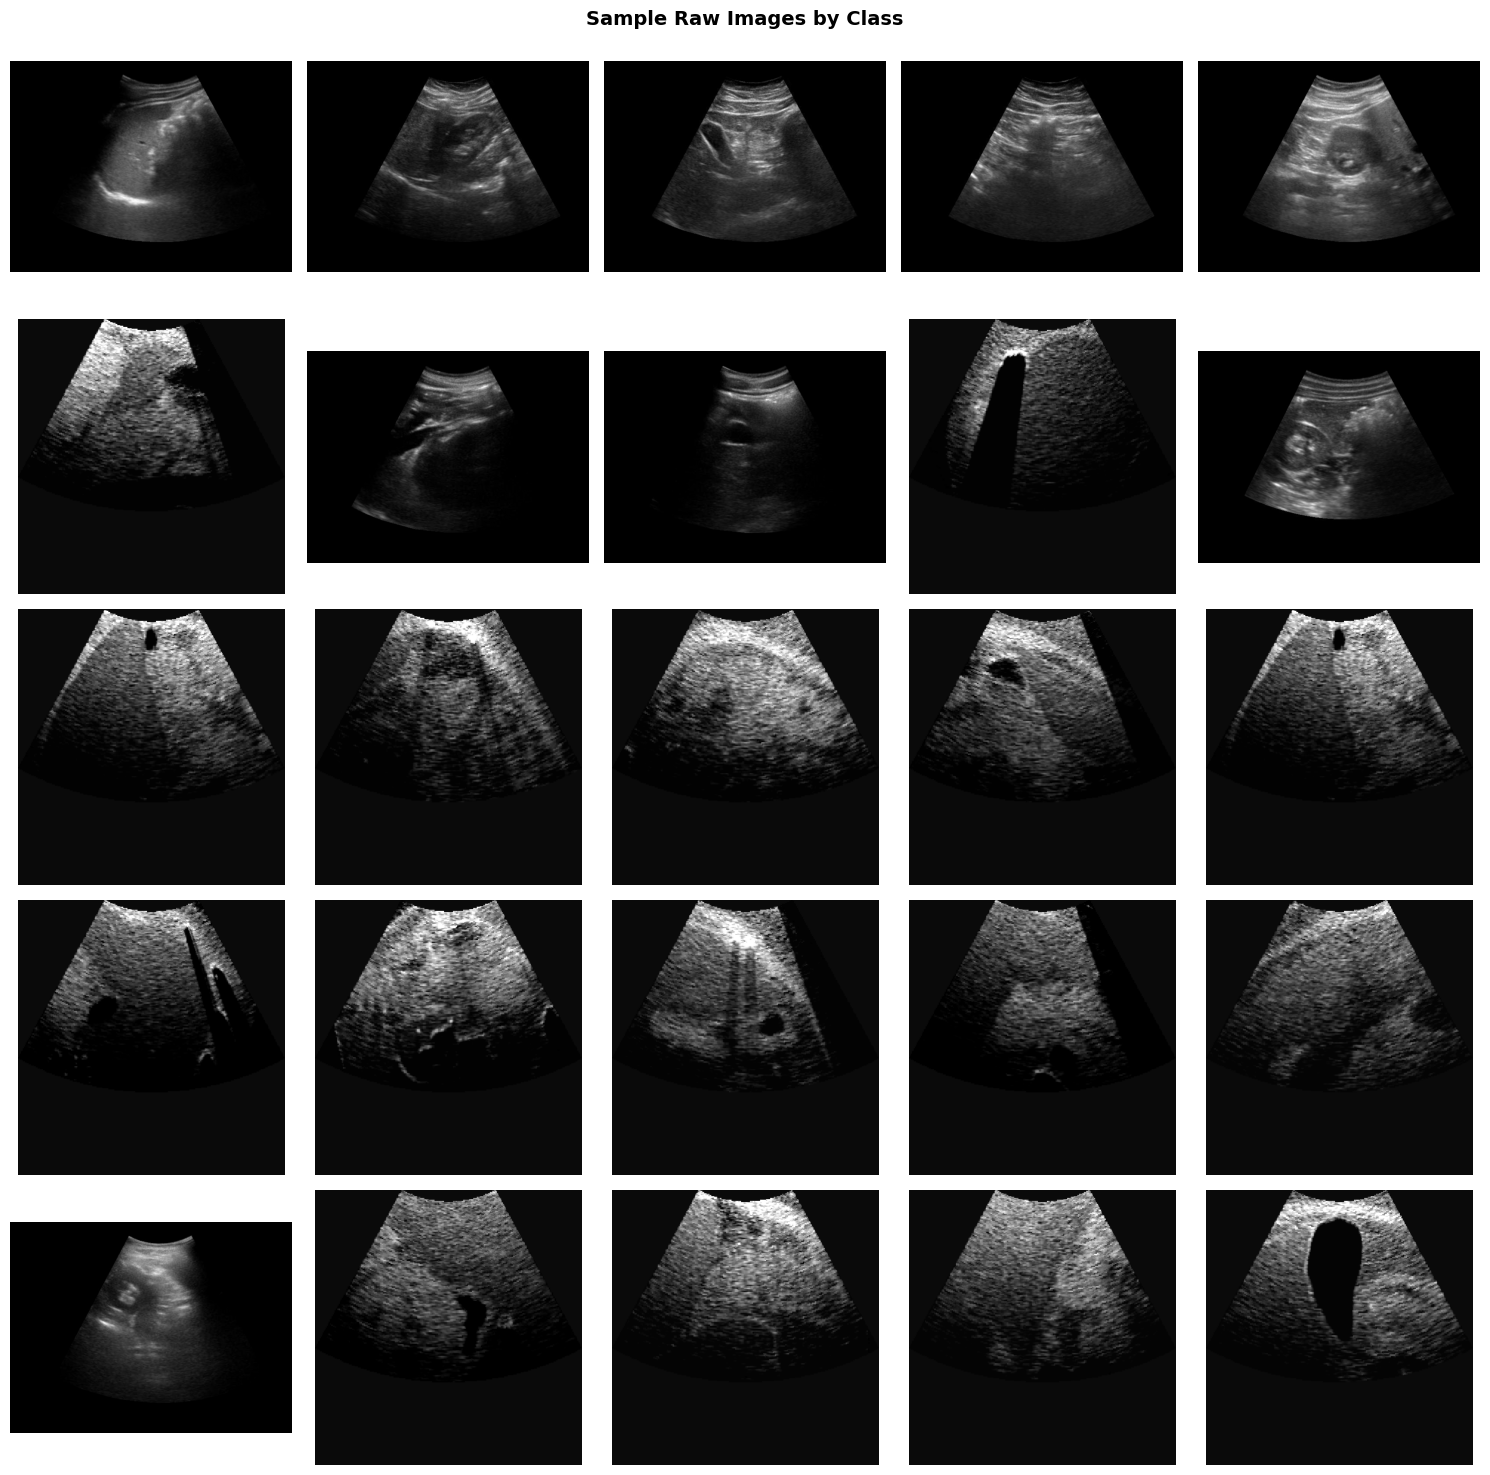

In [8]:
# Visualize sample images from each class
n_samples = 5
fig, axes = plt.subplots(len(all_classes), n_samples, figsize=(15, 3*len(all_classes)))

for i, cls in enumerate(all_classes):
    cls_path = RAW_DATA_DIR / cls
    images = sorted([f for f in cls_path.iterdir() if f.is_file()])[:n_samples]

    for j, img_file in enumerate(images):
        img = Image.open(img_file)

        if len(all_classes) == 1:
            ax = axes[j]
        else:
            ax = axes[i, j]

        ax.imshow(img, cmap='gray' if img.mode == 'L' else None)
        ax.axis('off')

        if j == 0:
            ax.set_ylabel(cls, fontsize=12, fontweight='bold')

plt.suptitle('Sample Raw Images by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4: Define Processing Function

**Important: Aspect Ratio Preservation**

The function now:
1. Resizes images to fit within 224x224 while **maintaining aspect ratio**
2. Adds black padding to create a square 224x224 image
3. Centers the resized image within the padded canvas

This prevents distortion of anatomical features in ultrasound images.

In [ ]:
def process_single_image(input_path, output_path, target_size=(224, 224)):
    """
    Process a single image:
    - Resize while maintaining aspect ratio
    - Pad to target_size (square)
    - Apply per-image min-max normalization
    - Save as PNG
    
    Returns: dict with processing metadata
    """
    try:
        # Read image
        with Image.open(input_path) as img:
            original_size = img.size
            original_mode = img.mode
            
            # Convert to grayscale or RGB
            if img.mode not in ['L', 'RGB']:
                img = img.convert('RGB')
            
            # Calculate resize dimensions maintaining aspect ratio
            width, height = img.size
            target_w, target_h = target_size
            
            # Calculate scale to fit within target size
            scale = min(target_w / width, target_h / height)
            new_width = int(width * scale)
            new_height = int(height * scale)
            
            # Resize using high-quality Lanczos resampling
            resized = img.resize((new_width, new_height), Image.Resampling.LANCZOS)
            
            # Create padded image (black padding)
            if img.mode == 'L':
                padded = Image.new('L', target_size, 0)
            else:
                padded = Image.new('RGB', target_size, (0, 0, 0))
            
            # Calculate padding offsets to center the image
            paste_x = (target_w - new_width) // 2
            paste_y = (target_h - new_height) // 2
            
            # Paste resized image onto padded canvas
            padded.paste(resized, (paste_x, paste_y))
            
            # Convert to numpy array for normalization
            arr = np.array(padded, dtype=np.float32)
            
            # Per-image min-max normalization
            if arr.ndim == 2:  # Grayscale
                min_val = arr.min()
                max_val = arr.max()
                if max_val > min_val:
                    arr = (arr - min_val) / (max_val - min_val) * 255.0
            else:  # RGB - normalize each channel independently
                for c in range(arr.shape[2]):
                    channel = arr[:, :, c]
                    min_val = channel.min()
                    max_val = channel.max()
                    if max_val > min_val:
                        arr[:, :, c] = (channel - min_val) / (max_val - min_val) * 255.0
            
            # Convert back to uint8 and save
            arr = np.round(arr).astype(np.uint8)
            processed = Image.fromarray(arr, mode=padded.mode)
            
            # Save as PNG
            processed.save(output_path, 'PNG')
            
            # Return metadata
            return {
                'success': True,
                'original_size': original_size,
                'original_mode': original_mode,
                'resized_size': (new_width, new_height),
                'final_size': target_size,
                'processed_mode': padded.mode,
                'scale_factor': scale,
                'padding': (paste_x, paste_y)
            }
    
    except Exception as e:
        return {
            'success': False,
            'error': str(e)
        }

print("✓ Processing function defined (with aspect ratio preservation)")

## Step 5: Process Images

In [10]:
# Create output directory structure
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for cls in CLASSES_TO_PROCESS:
    (OUTPUT_DIR / cls).mkdir(exist_ok=True)

print(f"Created output directory structure at: {OUTPUT_DIR}")

Created output directory structure at: /content/drive/MyDrive/Data/liver/processed


In [11]:
# Process all images
processing_log = defaultdict(list)
stats = {'total': 0, 'success': 0, 'failed': 0}

for cls in CLASSES_TO_PROCESS:
    cls_input = RAW_DATA_DIR / cls
    cls_output = OUTPUT_DIR / cls

    if not cls_input.is_dir():
        print(f"Warning: Class directory not found: {cls}")
        continue

    # Get all image files
    image_files = [f for f in cls_input.iterdir() if f.is_file()]

    print(f"\nProcessing class {cls}: {len(image_files)} images")

    for img_file in tqdm(image_files, desc=f"  {cls}"):
        # Change extension to .png
        output_fname = img_file.stem + '.png'
        output_path = cls_output / output_fname

        # Process image
        result = process_single_image(img_file, output_path, TARGET_SIZE)

        # Track statistics
        stats['total'] += 1
        if result['success']:
            stats['success'] += 1
        else:
            stats['failed'] += 1
            processing_log[cls].append({
                'filename': img_file.name,
                'error': result.get('error', 'Unknown error')
            })

print("\n" + "="*60)
print("PROCESSING COMPLETE")
print("="*60)
print(f"Total images processed: {stats['total']}")
print(f"Successful: {stats['success']}")
print(f"Failed: {stats['failed']}")

if stats['failed'] > 0:
    print("\nFailed images by class:")
    for cls, errors in processing_log.items():
        if errors:
            print(f"  {cls}: {len(errors)} failures")
            for err in errors[:3]:  # Show first 3
                print(f"    - {err['filename']}: {err['error']}")


Processing class F0: 2114 images


  F0:   0%|          | 0/2114 [00:00<?, ?it/s]/tmp/ipython-input-3492329805.py:42: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  processed = Image.fromarray(arr, mode=resized.mode)
  F0: 100%|██████████| 2114/2114 [01:12<00:00, 29.31it/s]



Processing class F1: 861 images


  F1: 100%|██████████| 861/861 [00:34<00:00, 24.92it/s]



Processing class F2: 793 images


...


Processing class F3: 857 images


  F3: 100%|██████████| 857/857 [00:47<00:00, 18.19it/s]



Processing class F4: 1698 images


  F4: 100%|██████████| 1698/1698 [01:10<00:00, 24.15it/s]


PROCESSING COMPLETE
Total images processed: 6323
Successful: 6323
Failed: 0


## Step 6: Verify Processed Data

In [12]:
# Verify all processed images have correct dimensions
print("Verifying processed images...\n")

verification_results = {}

for cls in CLASSES_TO_PROCESS:
    cls_path = OUTPUT_DIR / cls

    if not cls_path.is_dir():
        continue

    sizes = []
    modes = []

    for img_file in cls_path.iterdir():
        if img_file.is_file():
            try:
                with Image.open(img_file) as img:
                    sizes.append(img.size)
                    modes.append(img.mode)
            except Exception as e:
                print(f"  Error reading {cls}/{img_file.name}: {e}")

    verification_results[cls] = {
        'count': len(sizes),
        'unique_sizes': set(sizes),
        'unique_modes': set(modes)
    }

    print(f"Class {cls}:")
    print(f"  Images: {len(sizes)}")
    print(f"  Sizes: {verification_results[cls]['unique_sizes']}")
    print(f"  Modes: {verification_results[cls]['unique_modes']}")
    print()

# Check if all images are the target size
all_correct = all(
    v['unique_sizes'] == {TARGET_SIZE}
    for v in verification_results.values()
)

if all_correct:
    print("✓ All images successfully resized to target dimensions!")
else:
    print("⚠️ Some images have incorrect dimensions!")

Verifying processed images...

Class F0:
  Images: 2114
  Sizes: {(224, 224)}
  Modes: {'L'}

Class F1:
  Images: 861
  Sizes: {(224, 224)}
  Modes: {'L', 'RGB'}

Class F2:
  Images: 793
  Sizes: {(224, 224)}
  Modes: {'RGB'}

Class F3:
  Images: 857
  Sizes: {(224, 224)}
  Modes: {'RGB'}

Class F4:
  Images: 1698
  Sizes: {(224, 224)}
  Modes: {'L', 'RGB'}

✓ All images successfully resized to target dimensions!


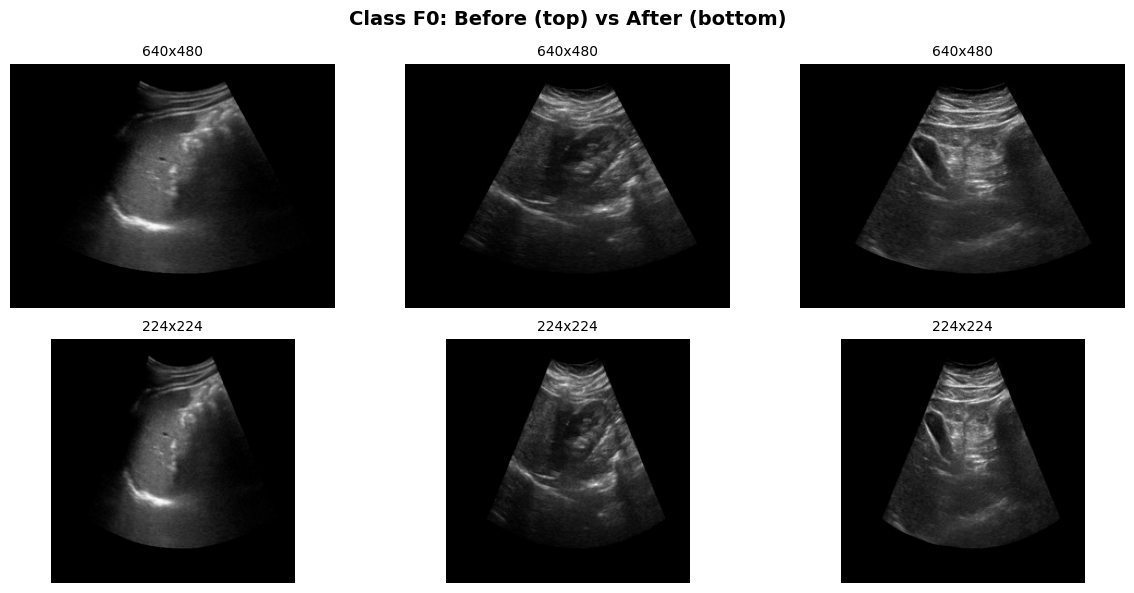

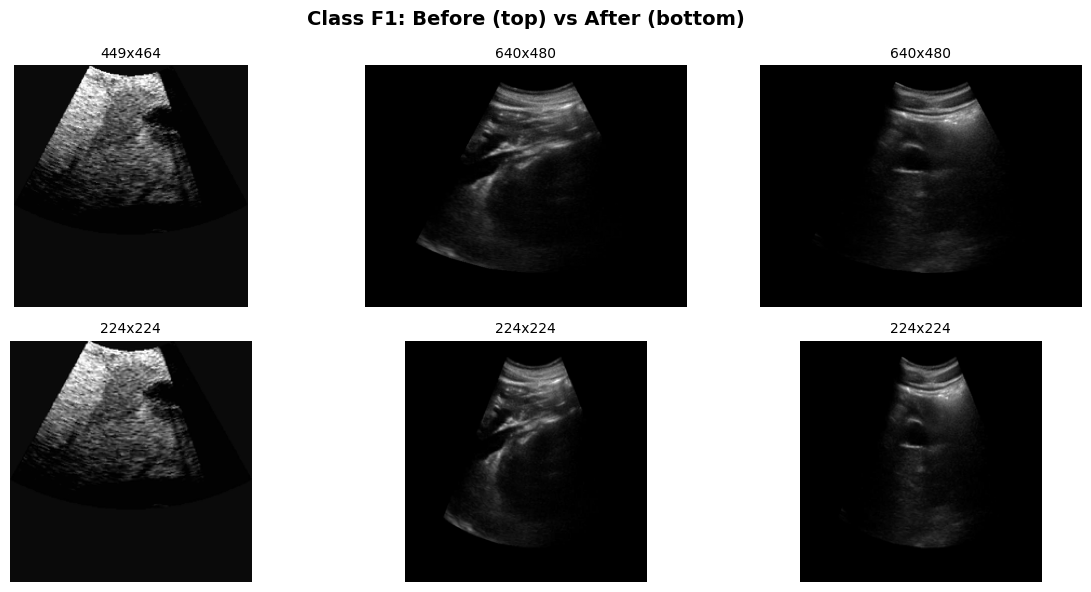

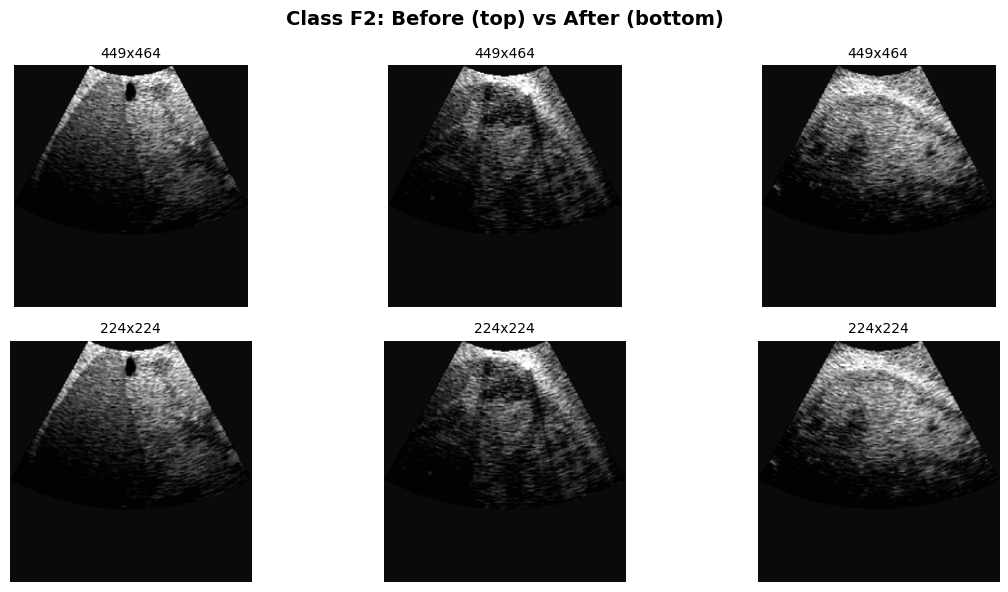

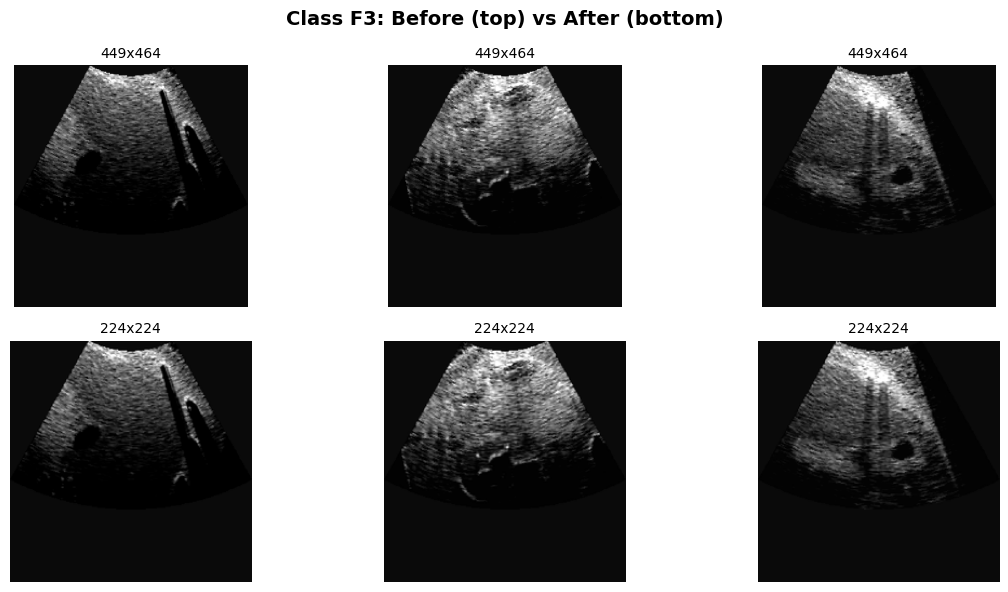

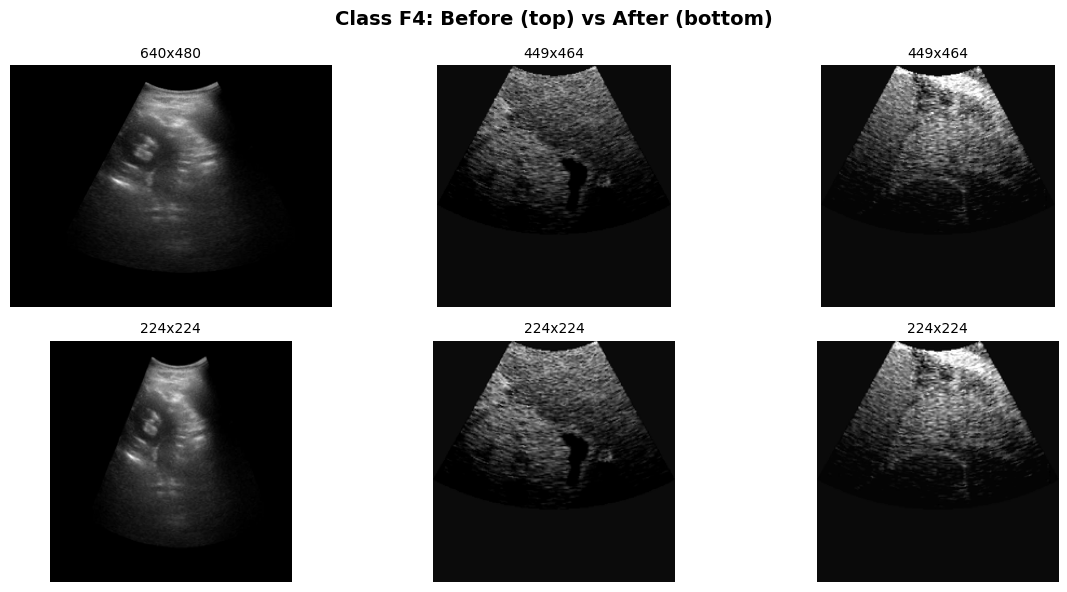

In [13]:
# Visualize before/after comparison
n_samples = 3

for cls in CLASSES_TO_PROCESS:
    raw_path = RAW_DATA_DIR / cls
    proc_path = OUTPUT_DIR / cls

    if not raw_path.is_dir() or not proc_path.is_dir():
        continue

    # Get sample files
    raw_files = sorted([f for f in raw_path.iterdir() if f.is_file()])[:n_samples]

    fig, axes = plt.subplots(2, n_samples, figsize=(12, 6))
    fig.suptitle(f'Class {cls}: Before (top) vs After (bottom)', fontsize=14, fontweight='bold')

    for j, raw_file in enumerate(raw_files):
        # Load raw image
        raw_img = Image.open(raw_file)

        # Load processed image (with .png extension)
        proc_file = proc_path / (raw_file.stem + '.png')

        if proc_file.exists():
            proc_img = Image.open(proc_file)
        else:
            proc_img = None

        # Plot raw
        axes[0, j].imshow(raw_img, cmap='gray' if raw_img.mode == 'L' else None)
        axes[0, j].set_title(f'{raw_img.size[0]}x{raw_img.size[1]}', fontsize=10)
        axes[0, j].axis('off')

        # Plot processed
        if proc_img:
            axes[1, j].imshow(proc_img, cmap='gray' if proc_img.mode == 'L' else None)
            axes[1, j].set_title(f'{proc_img.size[0]}x{proc_img.size[1]}', fontsize=10)
        axes[1, j].axis('off')

    plt.tight_layout()
    plt.show()

## Step 7: Save Processing Metadata

In [14]:
# Save processing metadata
metadata = {
    'preprocessing_version': '2.0_fixed',
    'target_size': TARGET_SIZE,
    'normalization_method': NORMALIZE_METHOD,
    'classes_processed': CLASSES_TO_PROCESS,
    'statistics': stats,
    'verification': {k: {'count': v['count'],
                         'sizes': list(v['unique_sizes']),
                         'modes': list(v['unique_modes'])}
                    for k, v in verification_results.items()}
}

metadata_path = OUTPUT_DIR / 'preprocessing_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata saved to: {metadata_path}")
print("\nPreprocessing pipeline complete!")

Metadata saved to: /content/drive/MyDrive/Data/liver/processed/preprocessing_metadata.json

Preprocessing pipeline complete!


## Summary

### What was fixed:
1. ✅ **Google Drive integration** - Data loaded from and saved to Drive
2. ✅ **No artificial augmentation** - Only original images are saved
3. ✅ **Standard size** - Resized to 224x224 (optimal for ResNet)
4. ✅ **Per-image normalization** - Each image normalized independently
5. ✅ **High-quality resampling** - Lanczos filter for best quality
6. ✅ **Lossless format** - Saved as PNG to avoid JPEG artifacts

### Next steps:
- Use the training pipeline with:
  - Data augmentation during training (not preprocessing)
  - Group-level train/val splitting (to prevent data leakage)
  - Proper regularization (dropout, weight decay)
  - Learning rate scheduling